In [22]:
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt


def model(X0, par, key, ts):
    mu, rho, sigma = par

    def step(state, iter):
        Xt, prev_key = state

        update_key, curr_key = jax.random.split(prev_key, 2)
        Xt1 = (mu + rho * (Xt - mu)) + sigma * jax.random.normal(update_key)

        return (Xt1, curr_key), Xt1

    _, loop_val = jax.lax.scan(
        step,
        init=(X0, key),
        xs=ts[1:],
    )

    return jnp.concatenate((X0[jnp.newaxis, ...], loop_val))

In [23]:
ts = jnp.arange(0,100,1)
par = (-1,.9,0.2)
rng_key = jax.random.key(10)
data_key,ys_data_key, X0_key, rng_key = jax.random.split(rng_key,4)

mu,rho,sigma = par
X0 = mu + sigma / jnp.sqrt(1 - rho**2) * jax.random.normal(X0_key)
observations = jnp.exp(1/2 * model(X0, par,data_key, ts)) * jax.random.normal(ys_data_key,shape = ts.shape)

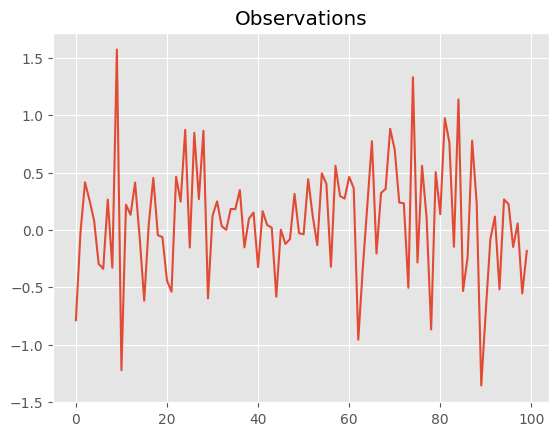

In [24]:
plt.title('Observations')
plt.style.use('ggplot')
plt.plot(ts,observations)
plt.show()

In [25]:
def likelihood(particles, observation, theta):
    mu, rho, sigma = theta
    return jax.scipy.stats.norm.logpdf(
        observation, loc=0., scale=jnp.exp(1/2 * particles)
    )

In [26]:
from algorithms.smc import particle_filter

def data_map(par, key):
    mu, log_rho, log_sigma = par
    rho = jax.nn.sigmoid(log_rho)
    sigma = jnp.exp(log_sigma)
    delta_t = 1.0
    pf_init_key, key = jax.random.split(key)

    num_particles = 25

    particles = mu + sigma / jnp.sqrt(1 - rho**2) * jax.random.normal(
        pf_init_key, shape=(num_particles,1)
    )

    pf_key, key = jax.random.split(key)
    particles, weights = particle_filter(
        model,
        observations,
        particles,
        pf_key,
        likelihood,
        (mu,rho,sigma),
        jnp.linspace(0, delta_t, 2),
    )

    expected_X = jnp.mean(particles, axis=0)

    return jnp.exp(1/2 * expected_X.squeeze())

In [27]:
test_runs = 100
test_key,rng_key = jax.random.split(rng_key)
test_keys = jax.random.split(test_key,test_runs)
test_runs = jax.vmap(data_map,in_axes = (None,0))((0.,0.0,jnp.log(0.5)),test_keys)

test_std = jnp.std(test_runs,axis = 0)

print(f"Average deviation: {jnp.mean(test_std)}")

Average deviation: 0.05939406156539917


In [28]:
from algorithms.EKI import EnsembleKalmanInversion

num_ensemble_members = 1000
init_ensemble_key, rng_key = jax.random.split(rng_key)

prior_mean = jnp.array([0.0, 0.0, jnp.log(0.5)])
initial_ensemble = jax.random.multivariate_normal(
    init_ensemble_key,
    prior_mean,
    cov=jnp.eye(len(prior_mean)),
    shape=(num_ensemble_members,),
)

data_covariance = 1.0 * jnp.eye(len(observations))

eki_key, rng_key = jax.random.split(rng_key)
(final_ensemble, _), _ = EnsembleKalmanInversion(
    initial_ensemble,
    data_map=lambda x, y: jax.vmap(data_map, in_axes=(0, 0))(x, y),
    observations=observations,
    observation_covariance=data_covariance,
    time_step=0.01,
    key=eki_key,
)

par_estimate = jnp.mean(final_ensemble, axis=0)
print(
    f"mu*: {par_estimate[0]}, rho*: {jax.nn.sigmoid(par_estimate[1])}, sigma*: {jnp.exp(par_estimate[2])}"
)

mu*: -2.276502847671509, rho*: 0.42454782128334045, sigma*: 0.3668674826622009
